<a href="https://colab.research.google.com/github/skywalker0803r/CFB/blob/main/%E6%BB%BE%E5%8B%95%E5%BC%8F%E9%A0%90%E6%B8%ACy1_R20973.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [90]:
import pandas as pd
import xgboost as xgb
import numpy as np
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import pickle
from pykalman import KalmanFilter

# --- Data Loading and Preprocessing (as in your original code) ---
df = pd.read_excel('/content/drive/MyDrive/脫硫劑優化改善/20240916-CFB2脫硫劑優化改善.xlsx')
col = df.columns
df = df.iloc[1:,:]
df.columns = col
df = df.set_index('Unnamed: 0')
df.index.name = 'datetime'
for i in df.columns:
    df[i] = pd.to_numeric(df[i], errors='coerce')

# select by rule
coal_low = df[df["MLUT4_FIQ-2BTCF"] < 20]
sox = df["MLUT4_AT-240"]
constant_sox_indices = sox[sox.shift(1) == sox][(sox.shift(2) == sox) & (sox.shift(-1) == sox)].index
constant_sox = df.loc[constant_sox_indices]
common_index = coal_low.index.union(constant_sox.index)
select_df = df.loc[~df.index.isin(common_index), :]

# select features
with open("features1.pkl", "rb") as f:
    features = pickle.load(f)

# define y_col
y_col = 'DeSOx_1st'
select_df = select_df[features+[y_col]]

# --- Modeling Code (Corrected Part) ---
def train_model(train_X, train_y):
    model = xgb.XGBRegressor(
        n_estimators=900,
        random_state=42,
        n_jobs=-1,
        learning_rate=0.028,
        max_depth=8,
        subsample=0.75,
        colsample_bytree=0.75,
        objective='reg:squarederror',
        tree_method='hist'
    )
    return model.fit(train_X, train_y)

# 1. 時間排序
select_df = select_df.sort_index().reset_index(drop=True)

# 2. 設定
target_col = y_col
time_windows_len = 100 #<--- 調整這裡

# 加入前一期目標欄位當特徵
select_df["prev_target"] = select_df[target_col].shift(1)

# 效率不應該低於0
select_df = select_df[select_df["prev_target"]>0]
select_df = select_df[select_df[y_col]>0]

#這個select_df的"prev_target"和y_col應該做平滑
def apply_kalman_filter(series,transition_covariance=0.3,observation_covariance=1.0,initial_state_covariance=1.0):
    series = series.fillna(method='ffill')
    kf = KalmanFilter(
        initial_state_mean=series.iloc[0],
        initial_state_covariance=initial_state_covariance,
        transition_matrices=1.0,
        observation_matrices=1.0,
        transition_covariance=transition_covariance,
        observation_covariance=observation_covariance,
        n_dim_obs=1
    )
    state_means, _ = kf.smooth(series.values)
    return state_means.flatten()

# 套用卡爾曼濾波
select_df["prev_target"] = apply_kalman_filter(select_df["prev_target"])
select_df[y_col] = apply_kalman_filter(select_df[y_col])


# 刪除因 shift 產生的 NaN 資料
select_df = select_df.dropna().reset_index(drop=True)

# 定義特徵欄位除了時間跟target_col不能用其他都可以用
feature_cols = [col for col in select_df.columns if col not in ['timestamp', target_col]]

# 開始訓練的索引
start_idx = time_windows_len

# 計算total_steps
total_steps = len(select_df) - start_idx

# 3. 儲存預測結果
predictions = []
abs_errors = []
thresholds = []
indices = []

# To store recent errors for threshold calculation for the *current* model
current_model_recent_errors = []
threshold_update_window = 100 # Calculate threshold from last 100 errors
percentile_for_threshold = 90 # 90th percentile of recent errors

# 4. 初始化進度條
pbar = tqdm(total=total_steps)

# 5. 動態預測迴圈
i = start_idx
error_exceeded_threshold = True  # Start with training a model

while i < len(select_df):
    # 早停判斷<不得移除>
    print(pbar)
    if pbar.n >= 1000: # This means it will stop after 1500 predictions, not 1000 training steps.
        break

    # 判斷是否要建模 並記錄
    if 'current_model' not in locals() or error_exceeded_threshold:
        train_df = select_df.iloc[i - time_windows_len:i]
        train_X = train_df[feature_cols]
        train_y = train_df[target_col]

        # train model start
        current_model = train_model(train_X, train_y)

        # Reset recent errors for the new model
        current_model_recent_errors = []
        # For the first prediction after re-training, we won't have enough recent errors
        # to calculate a meaningful threshold. We can set a default or wait.
        # Here, we'll simply let the first few errors build up before calculating.
        current_threshold = np.inf # Set a very high threshold initially for a newly trained model

        error_exceeded_threshold = False # Reset flag

    # 預測i
    test_row = select_df.iloc[i]
    test_X = test_row[feature_cols].values.reshape(1, -1)
    true_y = test_row[target_col]
    pred_y = current_model.predict(test_X)[0]
    error = abs(pred_y - true_y)

    # Add the current error to the list of recent errors for this model
    current_model_recent_errors.append(error)

    # If we have enough recent errors, calculate the threshold for the *current* model's performance
    if len(current_model_recent_errors) >= threshold_update_window:
        current_threshold = np.percentile(current_model_recent_errors[-threshold_update_window:], percentile_for_threshold)
    elif len(current_model_recent_errors) > 0: # If less than window size, use all available errors
        current_threshold = np.percentile(current_model_recent_errors, percentile_for_threshold)
    else:
        current_threshold = np.inf # Should ideally not happen after first few predictions

    # 紀錄
    predictions.append(pred_y)
    abs_errors.append(error)
    thresholds.append(current_threshold)
    indices.append(i)

    # 更新進度條
    pbar.update(1)

    # 根據預測i的結果判斷是否要設置error_exceeded_threshold
    # The check for re-training now uses the threshold calculated from actual recent test errors
    if error > current_threshold:
        error_exceeded_threshold = True
        # If error exceeds, a new model will be trained in the next iteration
        # and 'i' increments by 1
        i += 1
    else:
        # If error does not exceed, stay with the current model for the next prediction
        # 'i' increments by 1, and the loop will try to predict 'i+1' with the *same* model
        i += 1
        error_exceeded_threshold = False # Continue using current model

# 結束訓練
pbar.close()

# 6. 輸出結果表
result_df = select_df.loc[indices].copy()
result_df['prediction'] = predictions
result_df['abs_error'] = abs_errors
result_df['threshold'] = thresholds

# 預覽結果
print(result_df.head())

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 指標評估
y_true = result_df[y_col]
y_pred = result_df['prediction']

# Calculate R-squared
r2 = r2_score(y_true, y_pred)
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# Calculate MAPE
mape = np.mean(np.abs((y_true - y_pred) / y_true[y_true != 0])) * 100 if np.any(y_true != 0) else 0


# 假設 r2, rmse, mape 是事先計算好的指標
metrics = {
    'Metric': ['R-squared', 'RMSE', 'MAPE'],
    'Value': [r2, rmse, mape],
    'Unit': ['', '', '%']
}

df_metrics = pd.DataFrame(metrics)
df_metrics

  0%|          | 0/53611 [00:00<?, ?it/s]

  0%|          | 0/53611 [00:00<?, ?it/s]


  0%|          | 1/53611 [00:03<46:25:42,  3.12s/it]

  0%|          | 3/53611 [00:03<46:25:36,  3.12s/it]


  0%|          | 4/53611 [00:03<10:00:48,  1.49it/s]

...

  2%|▏         | 991/53611 [02:07<3:32:34,  4.13it/s]

  2%|▏         | 996/53611 [02:07<3:32:32,  4.13it/s]


  2%|▏         | 1000/53611 [02:08<1:52:28,  7.80it/s]

  2%|▏         | 1000/53611 [02:08<2:13:52,  6.55it/s]
     MLUT4_AIA792101B  MLUT4_TE-252D  MLUT4_AT-232A  MLUT4_FIC-231B  \
100          6.900000     857.535397     155.517031             0.0   
101          6.867849     859.417612     157.352135             0.0   
102          6.805979     860.947126     157.096622             0.0   
103          6.800000     859.555342     155.481862             0.0   
104          6.800000     856.837148     154.581236             0.0   

     MLUT4_TE-252F  MLUT4_FIC-231C  MLUT4_PIC-233  MLUT4_TE-252I      前爐SOx濃度  \
100     874.123596       16.858142     971.592529     880.261472  2117.256243   
101     874.862420       16.856887     971.485716     881.222624  2127.408170   
102     874.890518       16.855632     969.908187     883.643240  2129.567383   
103     872.808587       16.854377     970.941871     882.925170  2122.962504   
104     871.799639       16.853122     974.520517     882.827232  2119.318169   

     MLUT4_TE-252G  ...  MLUT4_

,Metric,Value,Unit
0,R-squared,0.973144,
1,RMSE,0.001844,
2,MAPE,0.133632,%


# 預測線圖

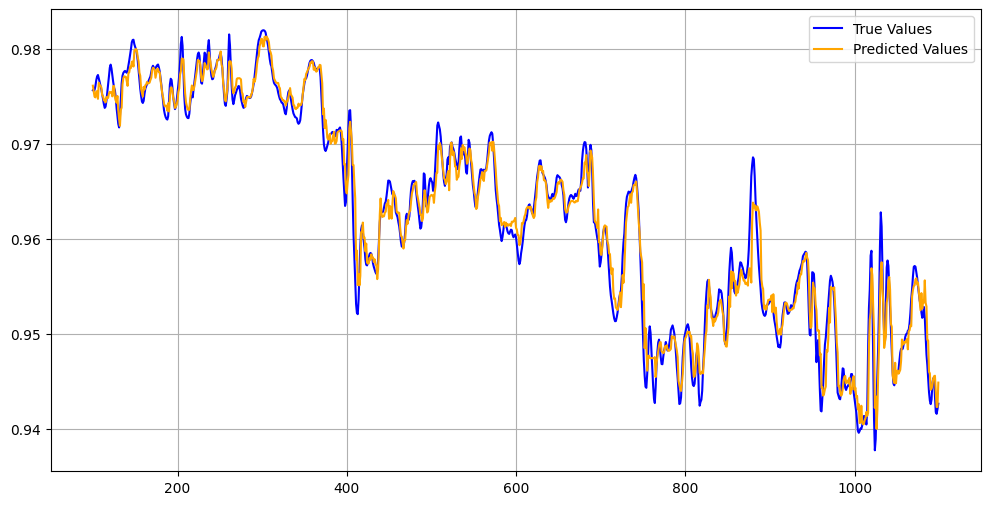

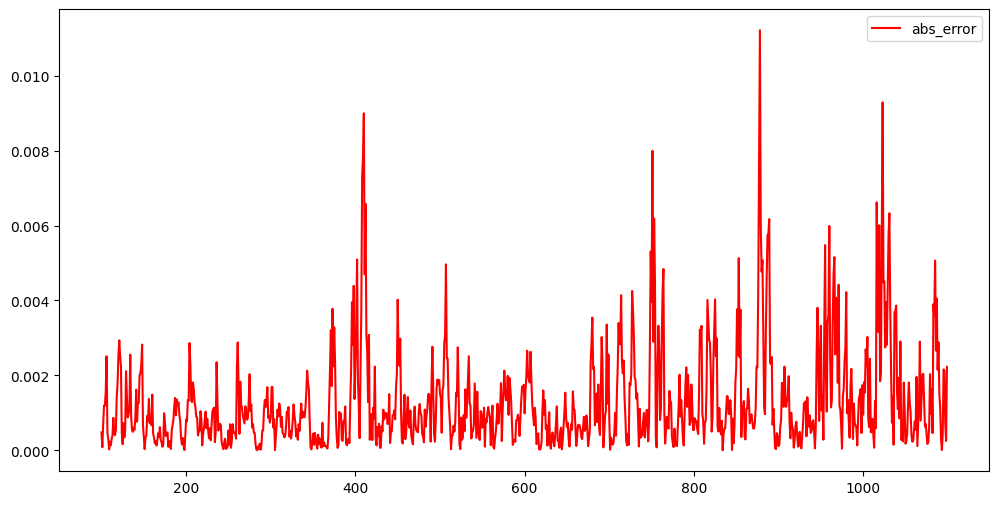

In [91]:
import matplotlib.pyplot as plt

# 畫圖
plt.figure(figsize=(12, 6))
plt.plot(result_df[y_col], label='True Values', color='blue')
plt.plot(result_df['prediction'], label='Predicted Values', color='orange')

plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(result_df['abs_error'], label='abs_error', color='red')#換個軸
plt.legend()
plt.show()


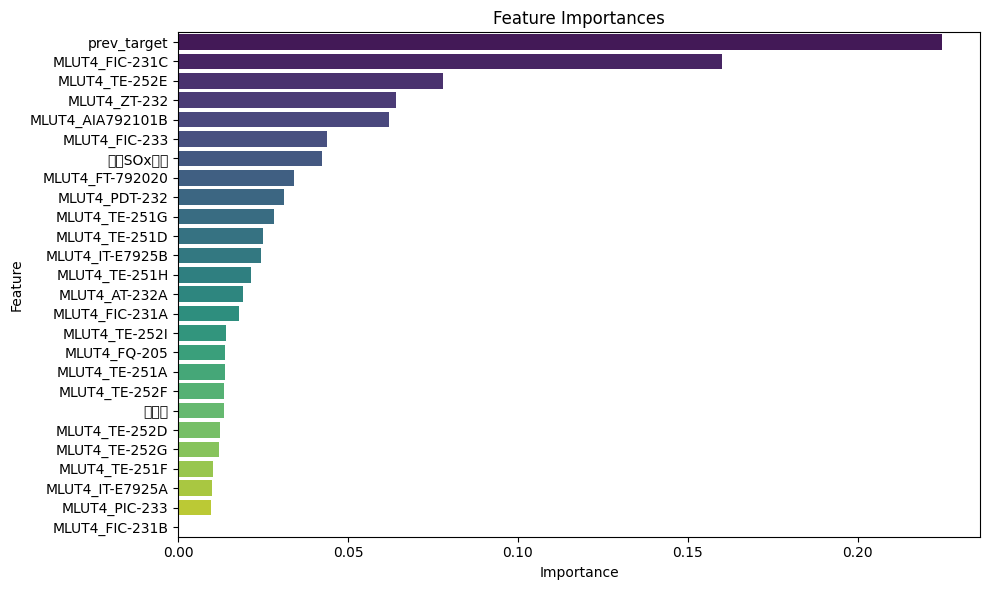

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 建立特徵重要度的 DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': train_X.columns,
    'Importance': current_model.feature_importances_
})

# 根據重要度排序
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 繪圖
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()


#比較濾波效果

In [93]:
import matplotlib.pyplot as plt

select_df = df.loc[~df.index.isin(common_index), :]
select_df = select_df[features+[y_col]]
select_df = select_df.sort_index().reset_index(drop=True)
select_df = select_df[select_df[y_col]>0]
origin = select_df[y_col]
after_filter = apply_kalman_filter(select_df[y_col])

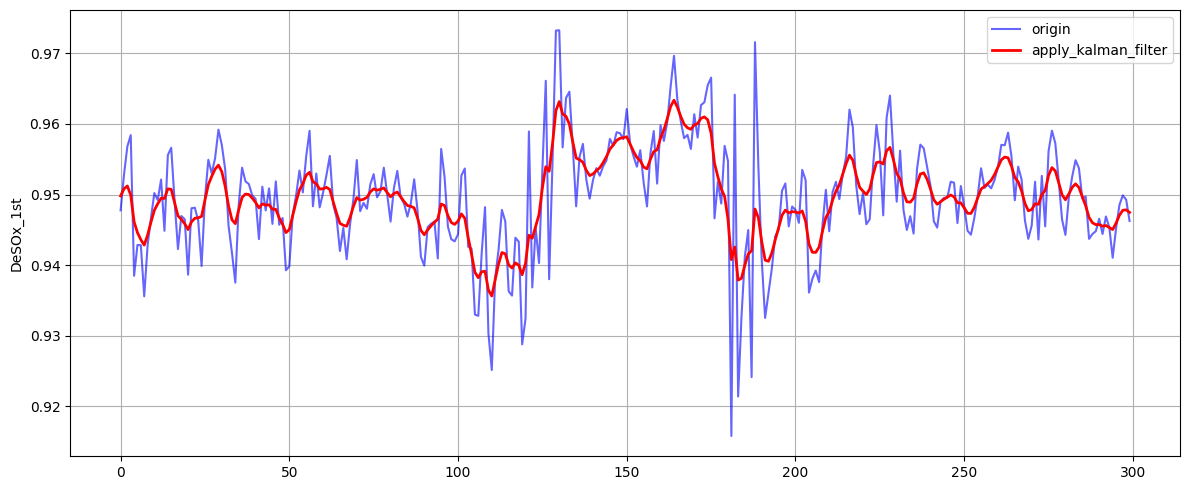

In [94]:
# 畫圖
plt.figure(figsize=(12, 5))
plt.plot(origin.values[-300:], label='origin', color='blue', alpha=0.6)
plt.plot(after_filter[-300:], label='apply_kalman_filter', color='red', linewidth=2)
plt.ylabel(y_col)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()